In [ ]:
import pandas as pd

 1. Загрузите выборку Wineпоадресуhttps://archive.ics.uci.edu/ml/machine
learning-databases/wine/wine.data

In [ ]:
url='https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data'

In [ ]:
data=pd.read_csv(url,header=None)

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


 2. Извлеките из данных признаки и классы. Класс записан в первом
 столбце (три варианта), признаки в столбцах со второго по по
следний. Более подробно о сути признаков можно прочитать по ад
ресу https://archive.ics.uci.edu/ml/datasets/Wine (см. также файл
 wine.names, приложенный к заданию)

In [ ]:
X=data.drop(0,axis=1)
y=data[1].astype(int)#изначальо тип float

 3. Оценку качества необходимо провести методом кросс-валидации по
 5 блокам (5-fold). Создайте генератор разбиений, который перемешивает выборку перед формированием блоков (shuffle=True). Для воспроизводимости результата, создавайте генератор KFold с фиксированным параметром random_state=42. В качестве меры качества используйте долю верных ответов (accuracy).

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score

kf=KFold(n_splits=5, shuffle=True, random_state=42)

 4. Найдите точность классификации на кросс-валидации для метода
 k ближайших соседей (sklearn.neighbors.KNeighborsClassifier), при
 k от 1 до 50. При каком k получилось оптимальное качество? Чему
 оно равно (число в интервале от 0 до 1)? Данные результаты и
 будут ответами на вопросы 1 и 2.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

scores=[]
for k in range(1,51):
  knn=KNeighborsClassifier(n_neighbors=k)
  score = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')
  scores.append(score.mean())#среднее при кросвалидачии берем
print(scores.index(max(scores))+1,max(scores))


20 0.5776190476190476


 5. Произведите масштабирование признаков с помощью функции
 sklearn.preprocessing.scale. Снова найдите оптимальное k на кросс
валидации.

In [ ]:
from sklearn.preprocessing import scale
X_scaled = scale(X)
scores_scaled=[]
for k in range(1,51):
  knn=KNeighborsClassifier(n_neighbors=k)
  score_scaled = cross_val_score(knn, X_scaled, y, cv=kf, scoring='accuracy')
  scores_scaled.append(score_scaled.mean())
print(scores_scaled.index(max(scores_scaled))+1, max(scores_scaled))

5 0.7017460317460318


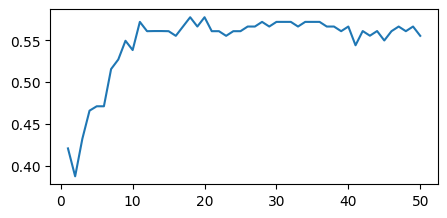

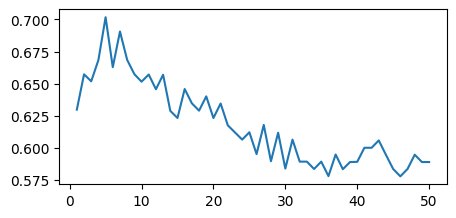

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.subplot(2, 1, 1)
plt.plot(range(1, 51), scores)
plt.figure(figsize=(5, 5))
plt.subplot(2, 1, 2)
plt.plot(range(1, 51), scores_scaled)

plt.show()#просто интересно посмотреть как меняется точность

 6. Какое значение k получилось оптимальным после приведения при
знаков к одному масштабу? Как изменилось значение качества?
 Приведите ответы на вопросы 3 и 4.

после стандартизации оптимальное число соседей 5, качество намного улучшилось выше я вывела график зависимости качества от соседей